In [5]:
from pathlib import Path
data_path = Path("../data/raw")

for item in data_path.iterdir():
    print(item.name)

sample_submission.csv
test
train


In [6]:
train_path = data_path / "train"

for item in train_path.iterdir():
    print(item.name)

44b6_0113de3b.geff
44b6_0113de3b.zarr
44b6_0b24845f.geff
44b6_0b24845f.zarr
44b6_0c582fdc.geff
44b6_0c582fdc.zarr
44b6_0db75fae.geff
44b6_0db75fae.zarr
44b6_12dfb391.geff
44b6_12dfb391.zarr
44b6_144b256d.geff
44b6_144b256d.zarr
44b6_1574802b.geff
44b6_1574802b.zarr
44b6_18ced818.geff
44b6_18ced818.zarr
44b6_1d530831.geff
44b6_1d530831.zarr
44b6_24264f12.geff
44b6_24264f12.zarr
44b6_267148e4.geff
44b6_267148e4.zarr
44b6_2a2eff9f.geff
44b6_2a2eff9f.zarr
44b6_2f31fc2f.geff
44b6_2f31fc2f.zarr
44b6_33b596bf.geff
44b6_33b596bf.zarr
44b6_341df25f.geff
44b6_341df25f.zarr
44b6_3a861e03.geff
44b6_3a861e03.zarr
44b6_3bb3690f.geff
44b6_3bb3690f.zarr
44b6_40c45f5a.geff
44b6_40c45f5a.zarr
44b6_415c0a3a.geff
44b6_415c0a3a.zarr
44b6_53f95252.geff
44b6_53f95252.zarr
44b6_551a5dba.geff
44b6_551a5dba.zarr
44b6_5740d24b.geff
44b6_5740d24b.zarr
44b6_587a1e22.geff
44b6_587a1e22.zarr
44b6_5f15d135.geff
44b6_5f15d135.zarr
44b6_668e0cc7.geff
44b6_668e0cc7.zarr
44b6_66f9292d.geff
44b6_66f9292d.zarr
44b6_706092f

In [7]:
from pathlib import Path

def count_files(path):
    return len(list(Path(path).rglob('*')))

print("Total files:", count_files(data_path))

Total files: 90775


In [8]:
from pathlib import Path

train_path = Path("../data/raw/train")
image_files = sorted(train_path.glob("*.zarr"))
print(f"Found {len(image_files)} zarr stores")

Found 199 zarr stores


In [9]:
if len(image_files) == 0:
    print("No images found. Check dataset structure or file extensions.")
else:
    print("Images found:", len(image_files))
    print("First store:", image_files[0].name)

Images found: 199
First store: 44b6_0113de3b.zarr


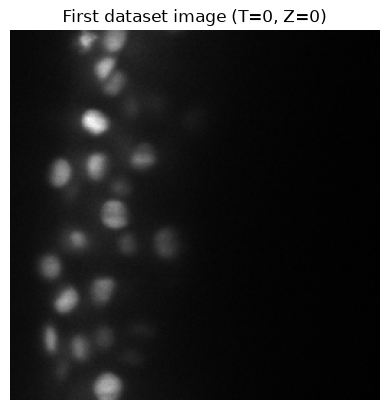

Shape: (100, 64, 256, 256), dtype: uint16


In [2]:
from pathlib import Path
import zarr
import matplotlib.pyplot as plt

image_files = sorted(Path("../data/raw/train").glob("*.zarr"))

store = zarr.open(image_files[0], mode="r")
img_data = store["0"][0, 0]

plt.imshow(img_data, cmap="gray")
plt.title("First dataset image (T=0, Z=0)")
plt.axis("off")
plt.show()
print(f"Shape: {store['0'].shape}, dtype: {store['0'].dtype}")

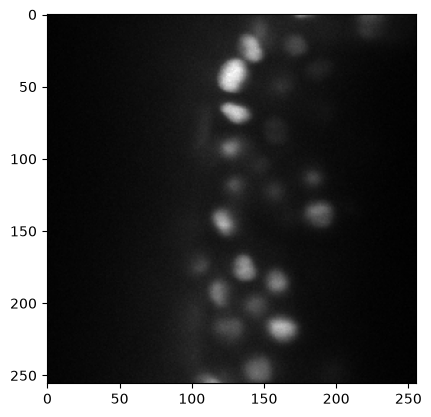

In [5]:
z = zarr.open(image_files[0], mode="r")
arr = z["0"]           # get the array node
frame = arr[0, 32]     # time=0, z-slice=32
plt.imshow(frame, cmap="gray")

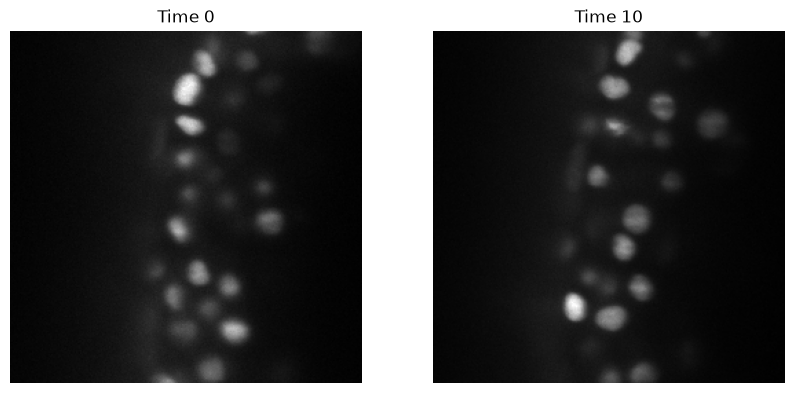

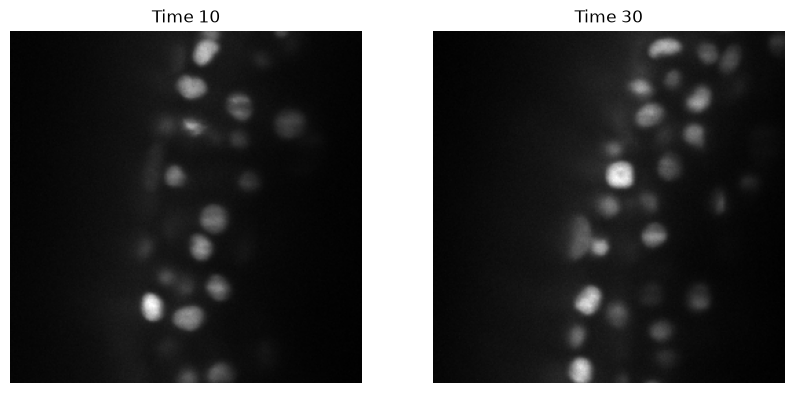

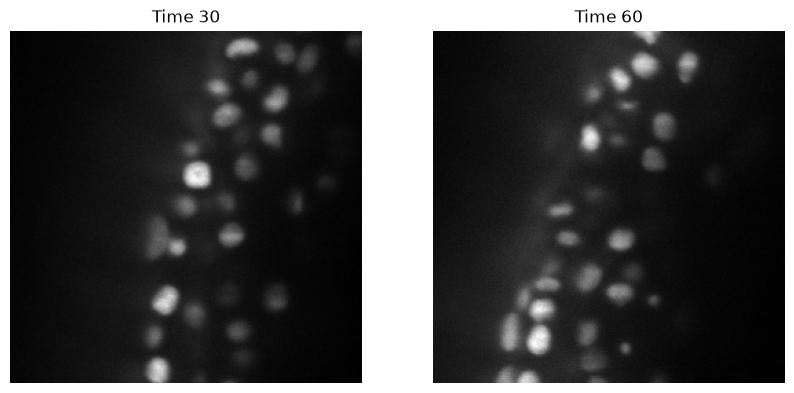

In [23]:
def compare_frames(zarr_data, t1, t2, z=32):
    import matplotlib.pyplot as plt
    
    arr = zarr_data["0"] if not hasattr(zarr_data, "ndim") else zarr_data
    
    f1 = arr[t1, z]
    f2 = arr[t2, z]
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(f1, cmap="gray")
    ax[0].set_title(f"Time {t1}")
    ax[0].axis("off")
    
    ax[1].imshow(f2, cmap="gray")
    ax[1].set_title(f"Time {t2}")
    ax[1].axis("off")
    
    plt.show()

compare_frames(z, t1=0, t2=10, z=32)
compare_frames(z, t1=10, t2=30, z=32)
compare_frames(z, t1=30, t2=60, z=32)

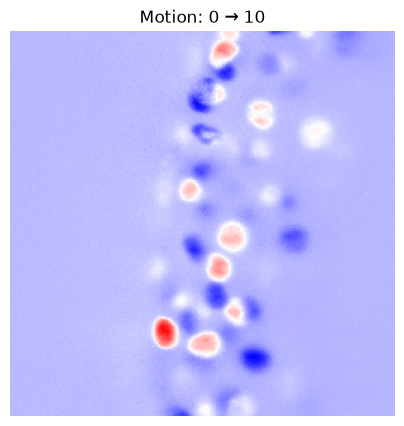

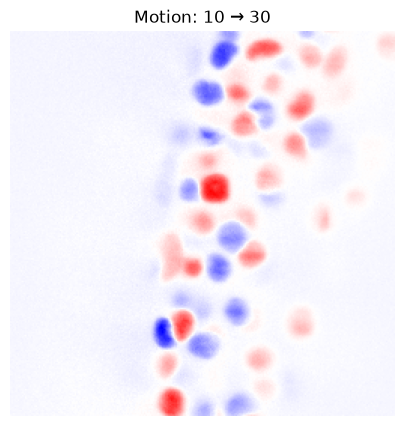

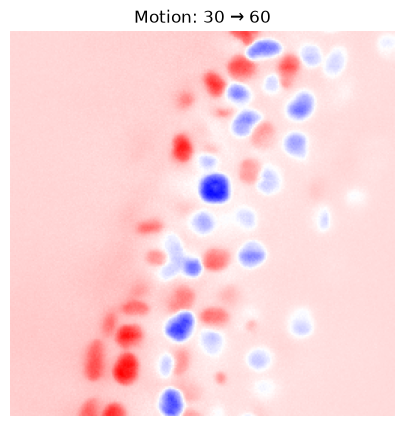

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def show_motion(zarr_data, t1, t2, z=32):
    f1 = zarr_data[t1, z]
    f2 = zarr_data[t2, z]
    
    diff = f2.astype(np.float32) - f1.astype(np.float32)
    
    plt.figure(figsize=(5,5))
    plt.imshow(diff, cmap="bwr")
    plt.title(f"Motion: {t1} → {t2}")
    plt.axis("off")
    plt.show()

show_motion(z["0"], t1=0, t2=10, z=32)
show_motion(z["0"], t1=10, t2=30, z=32)
show_motion(z["0"], t1=30, t2=60, z=32)

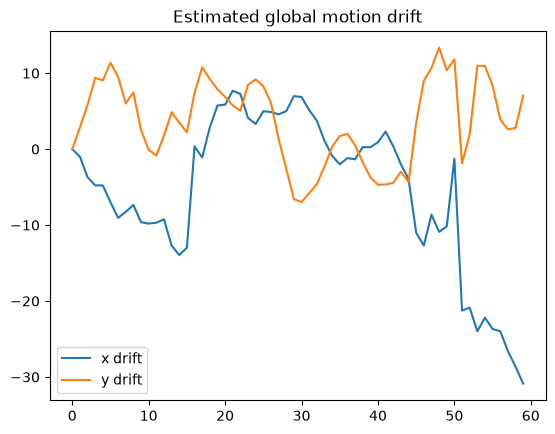

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def centroid(frame):
    y, x = np.where(frame > frame.mean())
    if len(x) == 0:
        return None
    return np.mean(x), np.mean(y)

def track_drift(zarr_data, z=32, t_max=60):
    drift = []
    base = centroid(zarr_data[0, z])
    for t in range(t_max):
        c = centroid(zarr_data[t, z])
        if c is None or base is None:
            continue
        dx = c[0] - base[0]
        dy = c[1] - base[1]
        drift.append((t, dx, dy))
    return drift

z = zarr.open(image_files[0], mode="r")
arr = z["0"]

drift = track_drift(arr, z=32, t_max=60)

t, dx, dy = zip(*drift)

plt.plot(t, dx, label="x drift")
plt.plot(t, dy, label="y drift")
plt.legend()
plt.title("Estimated global motion drift")
plt.show()